In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


### Part B : Data Acquisition

#### Json Parse:

In [3]:
Json_data = pd.read_json('customer_metadata.json')

customer_metadata_df = pd.json_normalize(Json_data['profile']) 
customer_metadata_df



,age,gender,region,education_level,employment_type
0,56,Male,South,Graduate,Salaried
1,69,Female,West,Secondary,Salaried
2,46,Male,West,Secondary,Self-Employed
3,32,Other,West,Secondary,Unemployed
4,60,Male,West,Graduate,Self-Employed
...,...,...,...,...,...
5995,55,Female,North,Graduate,Salaried
5996,61,Male,East,Primary,Unemployed
5997,44,Other,South,Secondary,Salaried
5998,26,Female,South,Primary,Self-Employed


#### Fetching From SQL :

In [4]:
import sqlite3

joint = sqlite3.connect("loan_repayment.db")

pd.read_sql("Select * from repayment_history" , joint)

,customer_id,missed_payments,last_payment_date
0,CUST100000,1,2021-05-24
1,CUST100001,2,2015-04-02
2,CUST100002,3,2017-10-01
3,CUST100003,4,2017-03-26
4,CUST100004,1,2022-05-13
...,...,...,...
5995,CUST105995,3,2018-03-13
5996,CUST105996,1,2023-10-13
5997,CUST105997,2,2016-05-09
5998,CUST105998,3,2016-08-19


#### Fetching from API :

In [5]:
import requests

url = "https://api.worldbank.org/v2/country/IND/indicator/NY.GDP.MKTP.CD?format=json"

response = requests.get(url)
data = response.json()

print(data)


[{'page': 1, 'pages': 2, 'per_page': 50, 'total': 66, 'sourceid': '2', 'lastupdated': '2026-04-08'}, [{'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2025', 'value': None, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2024', 'value': 3909891533858.08, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2023', 'value': 3638489096033.86, 'unit': '', 'obs_status': '', 'decimal': 0}, {'indicator': {'id': 'NY.GDP.MKTP.CD', 'value': 'GDP (current US$)'}, 'country': {'id': 'IN', 'value': 'India'}, 'countryiso3code': 'IND', 'date': '2022', 'value': 3346107287730.93, 'unit': '', 'obs_status': '', 'decimal': 0}, {'

#### Loading with CSV :

In [6]:
Original_Data = pd.read_csv("Bank_dataset.csv")

df = Original_Data.copy()

df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,1,62.0,Male,East,Post-Graduate,Salaried,2.984763e+05,153155.777800,Home,667.185355,2,252,23.358738,2022-08-28,0
1,2,65.0,Male,East,Graduate,NaN,1.249728e+06,401039.309370,Other,644.875261,3,154,11.944179,2016-11-18,0
2,3,18.0,Female,West,Secondary,Self-Employed,2.219560e+05,121350.363414,Education,450.499456,5,90,25.842356,2012-09-08,1
3,4,21.0,Male,South,Secondary,Salaried,2.529005e+05,116359.256631,Other,NaN,4,85,17.919534,2012-12-15,0
4,5,21.0,Female,East,Secondary,Salaried,NaN,NaN,Education,713.396778,1,116,46.349118,2023-05-24,0


### Part C : Data Understanding and Cleaning

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        6500 non-null   int64  
 1   age                6175 non-null   float64
 2   gender             6305 non-null   object 
 3   region             6500 non-null   object 
 4   education_level    6500 non-null   object 
 5   employment_type    6240 non-null   object 
 6   annual_income      6175 non-null   float64
 7   loan_amount        6175 non-null   float64
 8   loan_purpose       6500 non-null   object 
 9   credit_score       6240 non-null   float64
 10  repayment_history  6500 non-null   int64  
 11  transaction_count  6500 non-null   int64  
 12  spending_ratio     6500 non-null   float64
 13  join_date          6500 non-null   object 
 14  default_flag       6500 non-null   int64  
dtypes: float64(5), int64(4), object(6)
memory usage: 761.8+ KB


,customer_id,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,6500.000000,6175.000000,6.175000e+03,6.175000e+03,6240.000000,6500.000000,6500.000000,6500.000000,6500.000000
mean,3250.500000,43.545101,2.409075e+05,1.074462e+05,648.222984,2.236462,150.960000,28.753408,0.029231
std,1876.532707,15.103622,3.290335e+05,1.731338e+05,115.758159,1.988332,86.185678,15.955490,0.168466
min,1.000000,18.000000,1.130800e+04,2.459662e+03,300.000000,0.000000,1.000000,0.407626,0.000000
25%,1625.750000,30.000000,1.020031e+05,3.783471e+04,569.397036,1.000000,77.000000,16.263690,0.000000
50%,3250.500000,44.000000,1.639674e+05,6.573490e+04,650.115927,2.000000,151.000000,26.693205,0.000000
75%,4875.250000,57.000000,2.710157e+05,1.138310e+05,731.866052,3.000000,225.000000,39.058783,0.000000
max,6500.000000,69.000000,7.983479e+06,6.244591e+06,850.000000,15.000000,299.000000,88.825329,1.000000


In [8]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

,Missing Count,Percentage(%)
customer_id,0,0.0
age,325,5.0
gender,195,3.0
region,0,0.0
education_level,0,0.0
employment_type,260,4.0
annual_income,325,5.0
loan_amount,325,5.0
loan_purpose,0,0.0
credit_score,260,4.0


In [9]:
df.dtypes

customer_id            int64
age                  float64
gender                object
region                object
education_level       object
employment_type       object
annual_income        float64
loan_amount          float64
loan_purpose          object
credit_score         float64
repayment_history      int64
transaction_count      int64
spending_ratio       float64
join_date             object
default_flag           int64
dtype: object

In [10]:
df = df.drop(columns=['customer_id'])

In [11]:
Missing_Num = df[['annual_income', 'loan_amount','credit_score','age']]
Missing_cat = df[['gender' , 'employment_type']]

In [12]:
num_imputer = SimpleImputer(strategy='median')
df['annual_income'] = num_imputer.fit_transform(df[['annual_income']])
df['loan_amount'] = num_imputer.fit_transform(df[['loan_amount']])
df['credit_score'] = num_imputer.fit_transform(df[['credit_score']])
df['age'] = num_imputer.fit_transform(df[['age']])


In [13]:
df['annual_income'] = df['annual_income'].round(0)
df['loan_amount'] = df['loan_amount'].round(0)

In [14]:
def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['gender'] = random_impute(df['gender'])
df['employment_type'] = random_impute(df['employment_type'])

In [15]:
df.isnull().sum()

age                  0
gender               0
region               0
education_level      0
employment_type      0
annual_income        0
loan_amount          0
loan_purpose         0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
join_date            0
default_flag         0
dtype: int64

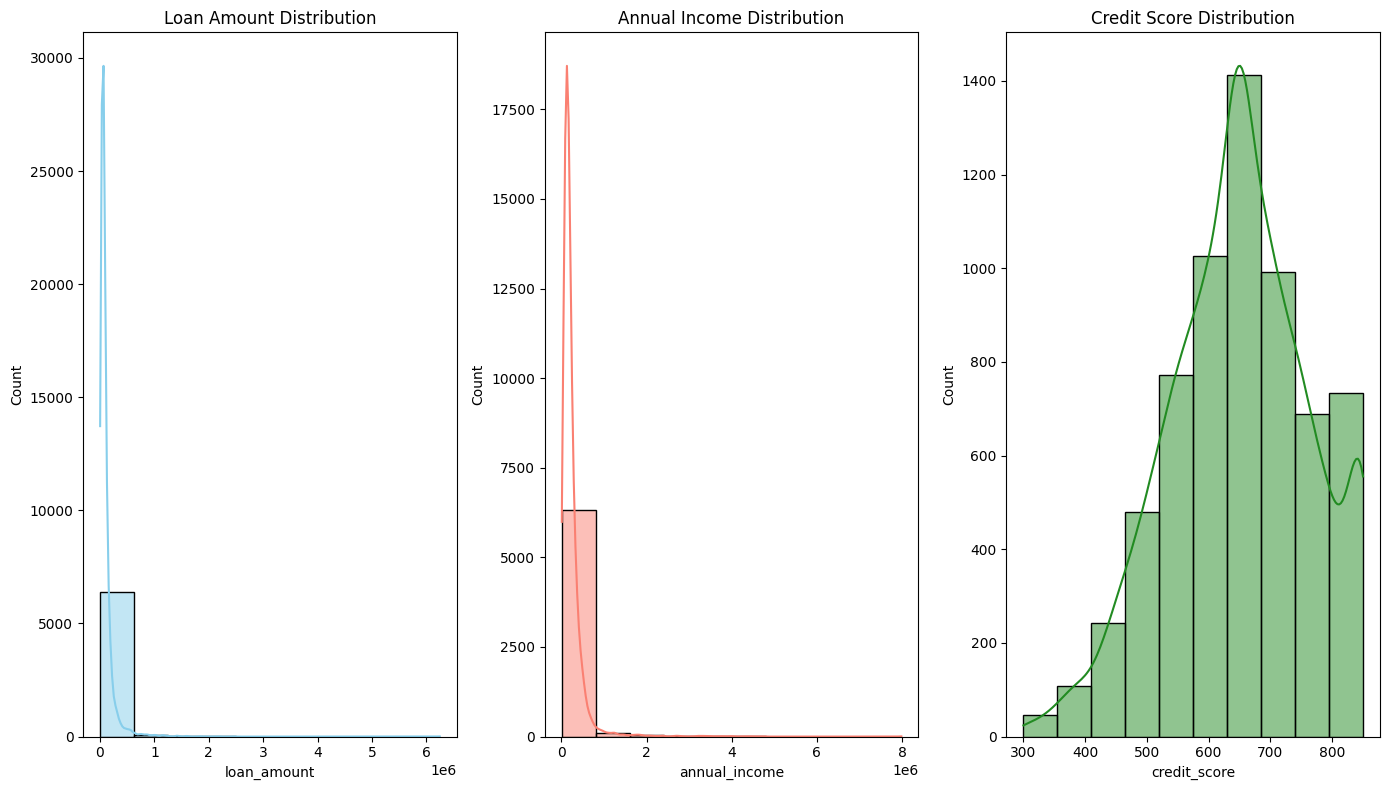

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 8))

sns.histplot(df['loan_amount'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Loan Amount Distribution')

sns.histplot(df['annual_income'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['credit_score'], bins=10, kde=True, ax=axes[2], color='forestgreen')
axes[2].set_title('Credit Score Distribution')


plt.tight_layout()
plt.show()


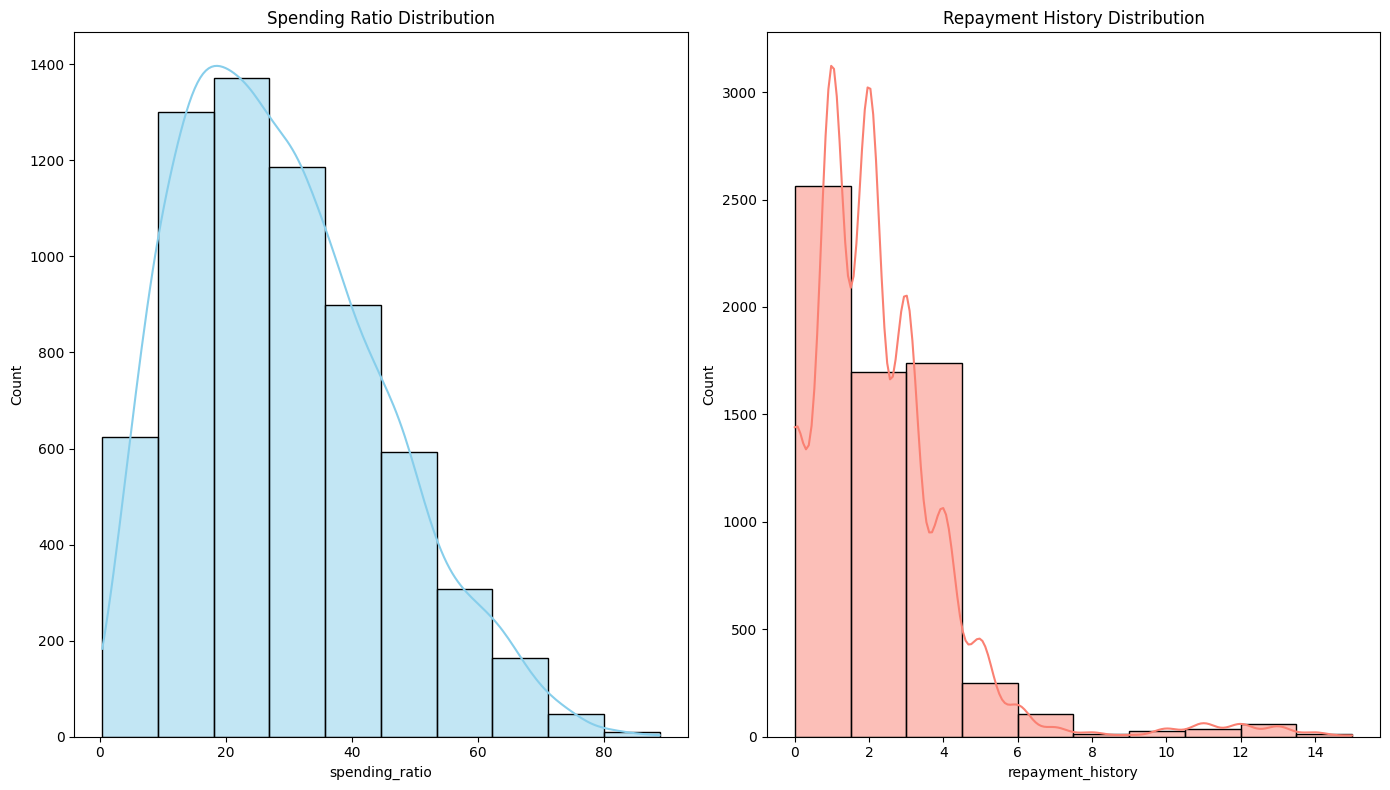

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['spending_ratio'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Spending Ratio Distribution')

sns.histplot(df['repayment_history'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Repayment History Distribution')

plt.tight_layout()
plt.show()


### Part D: Outlier Handling

In [18]:
Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['annual_income'] = np.clip(df['annual_income'], lower, upper)

In [19]:
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['loan_amount'] = np.clip(df['loan_amount'], lower, upper)

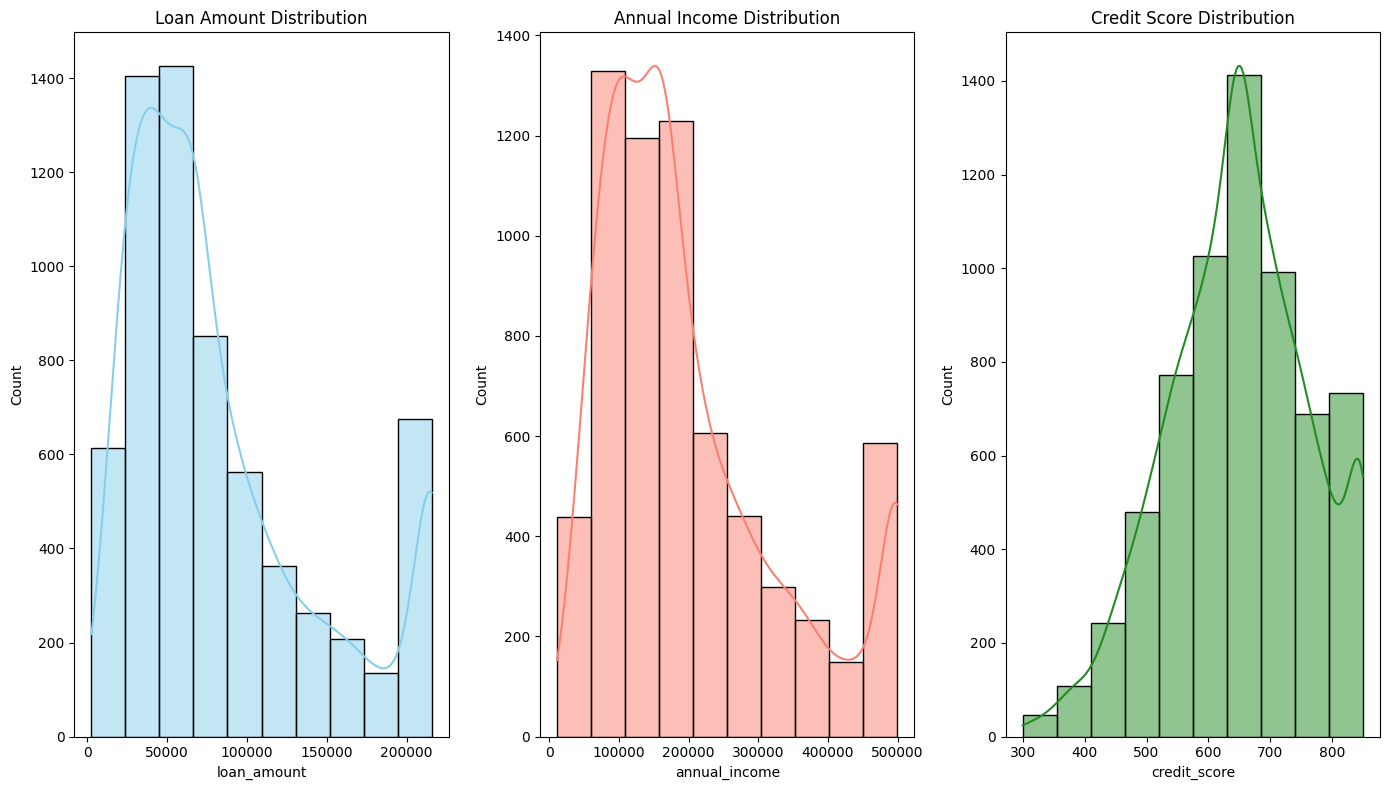

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 8))

sns.histplot(df['loan_amount'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Loan Amount Distribution')

sns.histplot(df['annual_income'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['credit_score'], bins=10, kde=True, ax=axes[2], color='forestgreen')
axes[2].set_title('Credit Score Distribution')


plt.tight_layout()
plt.show()



### Feature Transformation

In [21]:
transform_cols = ['annual_income', 'loan_amount', 'spending_ratio']

pt = PowerTransformer(method='yeo-johnson')

df[transform_cols] = pt.fit_transform(df[transform_cols])

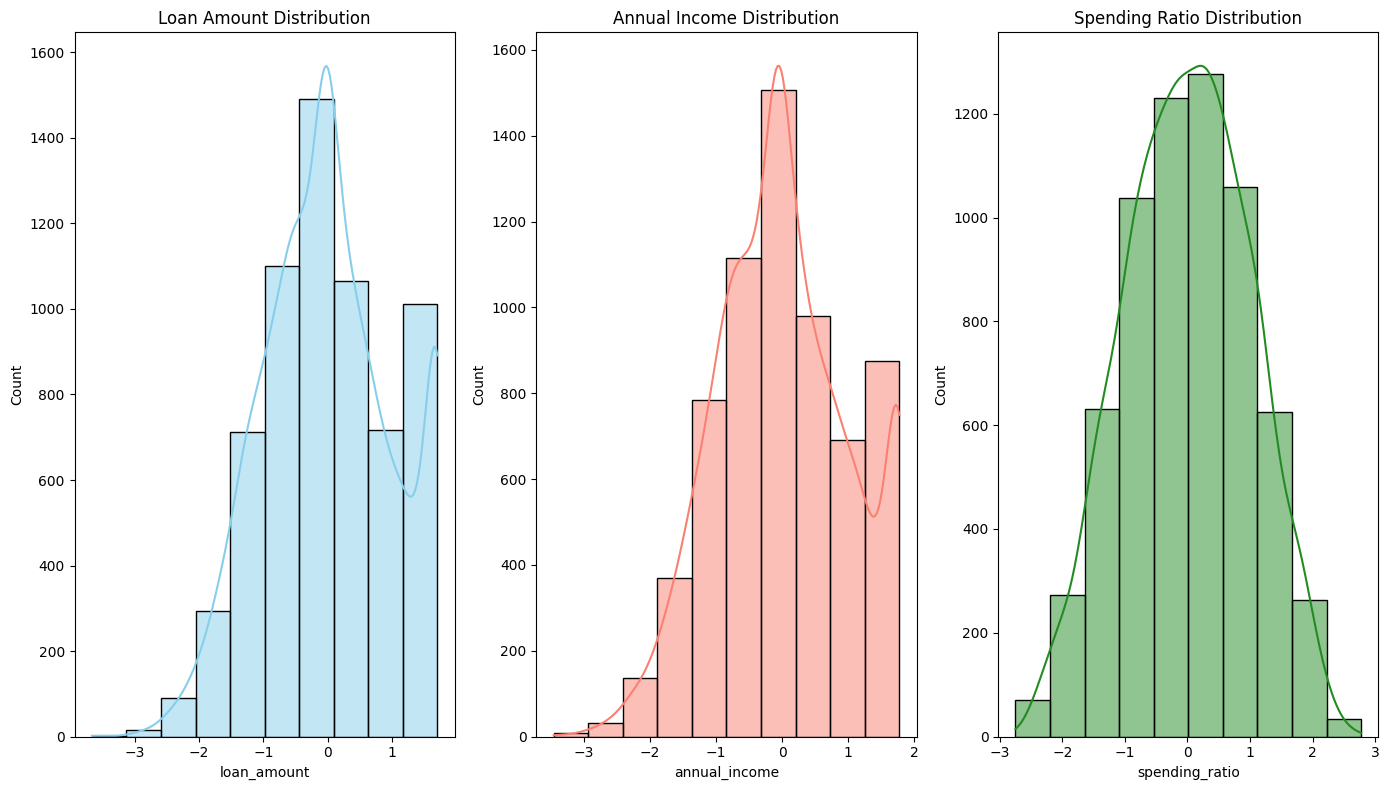

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 8))

sns.histplot(df['loan_amount'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Loan Amount Distribution')

sns.histplot(df['annual_income'], bins=10, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['spending_ratio'], bins=10, kde=True, ax=axes[2], color='forestgreen')
axes[2].set_title('Spending Ratio Distribution')


plt.tight_layout()
plt.show()

In [23]:
df

,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,62.0,Male,East,Post-Graduate,Salaried,0.903363,1.184566,Home,667.185355,2,252,-0.197935,2022-08-28,0
1,65.0,Male,East,Graduate,Self-Employed,1.777819,1.712653,Other,644.875261,3,154,-1.092661,2016-11-18,0
2,18.0,Female,West,Secondary,Self-Employed,0.426464,0.838233,Education,450.499456,5,90,-0.034897,2012-09-08,1
3,21.0,Male,South,Secondary,Salaried,0.634302,0.776826,Other,650.115927,4,85,-0.588345,2012-12-15,0
4,21.0,Female,East,Secondary,Salaried,-0.042211,-0.026504,Education,713.396778,1,116,1.086156,2023-05-24,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,47.0,Male,West,Graduate,Salaried,-1.129698,-1.029544,Other,812.134372,0,9,0.373928,2013-08-11,0
6496,65.0,Other,East,Primary,Salaried,-2.060411,-2.407724,Home,581.430661,12,76,-0.364207,2017-03-10,1
6497,56.0,Female,North,Post-Graduate,Self-Employed,0.695446,0.946315,Business,650.115927,1,88,0.649121,2011-05-17,0
6498,56.0,Female,East,Secondary,Self-Employed,0.185609,0.439327,Business,594.540852,3,252,-0.262593,2013-01-28,0


### Part E : Feature Engineering

In [24]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Primary', 'Secondary', 'Graduate', 'Post-Graduate']]
)

df['education_level'] = ordinal_encoder.fit_transform(df[['education_level']])


In [25]:
onehot_cols = ['gender', 'region', 'employment_type', 'loan_purpose']

onehot_encoder = OneHotEncoder(drop='first',  sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(onehot_cols),
    index=df.index
)

df = df.drop(columns=onehot_cols)
df = pd.concat([df, encoded_df], axis=1)

In [26]:
df['join_date'] = pd.to_datetime(df['join_date'])

df['year'] = df['join_date'].dt.year
df['month'] = df['join_date'].dt.month

df = df.drop(columns=['join_date'])

In [27]:
df

,age,education_level,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,gender_Male,...,region_South,region_West,employment_type_Self-Employed,employment_type_Unemployed,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,year,month
0,62.0,3.0,0.903363,1.184566,667.185355,2,252,-0.197935,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2022,8
1,65.0,2.0,1.777819,1.712653,644.875261,3,154,-1.092661,0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2016,11
2,18.0,1.0,0.426464,0.838233,450.499456,5,90,-0.034897,1,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,2012,9
3,21.0,1.0,0.634302,0.776826,650.115927,4,85,-0.588345,0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2012,12
4,21.0,1.0,-0.042211,-0.026504,713.396778,1,116,1.086156,0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2023,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,47.0,2.0,-1.129698,-1.029544,812.134372,0,9,0.373928,0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2013,8
6496,65.0,0.0,-2.060411,-2.407724,581.430661,12,76,-0.364207,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2017,3
6497,56.0,3.0,0.695446,0.946315,650.115927,1,88,0.649121,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2011,5
6498,56.0,1.0,0.185609,0.439327,594.540852,3,252,-0.262593,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2013,1


### Feature Construction

In [28]:
df['debt_income_ratio'] = df['loan_amount'] / df['annual_income']
df['income_per_txn'] = df['annual_income'] / df['transaction_count']
df['risk_score'] = df['loan_amount'] / df['credit_score']

### Feature Scaling

In [29]:
numeric_cols = numeric_cols = ['annual_income','loan_amount','credit_score','transaction_count','spending_ratio',
    'repayment_history','debt_income_ratio','income_per_txn','risk_score',
]

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [30]:
df

,age,education_level,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,gender_Male,...,employment_type_Unemployed,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,year,month,debt_income_ratio,income_per_txn,risk_score
0,62.0,3.0,0.903363,1.184566,0.166533,-0.118934,1.172443,-0.197935,0,1.0,...,0.0,0.0,0.0,1.0,0.0,2022,8,0.032315,0.040579,1.088160
1,65.0,2.0,1.777819,1.712653,-0.030186,0.384039,0.035275,-1.092661,0,1.0,...,0.0,0.0,0.0,0.0,1.0,2016,11,0.015509,0.160539,1.628294
2,18.0,1.0,0.426464,0.838233,-1.744094,1.389985,-0.707365,-0.034897,1,0.0,...,0.0,0.0,1.0,0.0,0.0,2012,9,0.063916,0.057967,1.140439
3,21.0,1.0,0.634302,0.776826,0.016023,0.887012,-0.765383,-0.588345,0,1.0,...,0.0,0.0,0.0,0.0,1.0,2012,12,0.028132,0.099019,0.731946
4,21.0,1.0,-0.042211,-0.026504,0.574002,-0.621907,-0.405667,1.086156,0,0.0,...,0.0,0.0,1.0,0.0,0.0,2023,5,-0.000694,-0.018932,-0.023999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,47.0,2.0,-1.129698,-1.029544,1.444620,-1.124879,-1.647268,0.373928,0,1.0,...,0.0,0.0,0.0,0.0,1.0,2013,8,0.012997,-1.905216,-0.779022
6496,65.0,0.0,-2.060411,-2.407724,-0.589609,4.910795,-0.869817,-0.364207,1,0.0,...,0.0,0.0,0.0,1.0,0.0,2017,3,0.025421,-0.422038,-2.541996
6497,56.0,3.0,0.695446,0.946315,0.016023,-0.621907,-0.730572,0.649121,0,0.0,...,0.0,0.0,0.0,0.0,0.0,2011,5,0.034703,0.105657,0.891906
6498,56.0,1.0,0.185609,0.439327,-0.474010,0.384039,1.172443,-0.262593,0,0.0,...,0.0,0.0,0.0,0.0,0.0,2013,1,0.083304,-0.002347,0.452180


In [31]:
Clean_dataset = df.copy()

Clean_dataset.head()

,age,education_level,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,gender_Male,...,employment_type_Unemployed,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,year,month,debt_income_ratio,income_per_txn,risk_score
0,62.0,3.0,0.903363,1.184566,0.166533,-0.118934,1.172443,-0.197935,0,1.0,...,0.0,0.0,0.0,1.0,0.0,2022,8,0.032315,0.040579,1.088160
1,65.0,2.0,1.777819,1.712653,-0.030186,0.384039,0.035275,-1.092661,0,1.0,...,0.0,0.0,0.0,0.0,1.0,2016,11,0.015509,0.160539,1.628294
2,18.0,1.0,0.426464,0.838233,-1.744094,1.389985,-0.707365,-0.034897,1,0.0,...,0.0,0.0,1.0,0.0,0.0,2012,9,0.063916,0.057967,1.140439
3,21.0,1.0,0.634302,0.776826,0.016023,0.887012,-0.765383,-0.588345,0,1.0,...,0.0,0.0,0.0,0.0,1.0,2012,12,0.028132,0.099019,0.731946
4,21.0,1.0,-0.042211,-0.026504,0.574002,-0.621907,-0.405667,1.086156,0,0.0,...,0.0,0.0,1.0,0.0,0.0,2023,5,-0.000694,-0.018932,-0.023999
